# 00 - Setup & Data Pipeline

**Obiettivo:** Configurare l'ambiente, scaricare il dataset Plant Village e creare gli split train/val/test.

**Struttura:**
1. Setup & Imports
2. Crea directory
3. Download dataset
4. Organizza per classe
5. Crea train/val/test split
6. Data exploration

## 1. Setup & Imports

In [1]:
import os
import sys
import shutil
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent / 'src'))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All imports successful!')
print(f'Working directory: {Path.cwd()}')

✅ All imports successful!
Working directory: /Users/marco/Documents/repos/ComputerVisionProject/notebooks


## 2. Crea Directory

In [2]:
ROOT = Path.cwd().parent

dirs = [
    ROOT / 'data' / 'raw',
    ROOT / 'data' / 'processed',
    ROOT / 'results' / 'models' / 'v1_hog_svm',
    ROOT / 'results' / 'models' / 'v2_custom_cnn',
    ROOT / 'results' / 'models' / 'v3_transfer_learning',
    ROOT / 'results' / 'metrics',
    ROOT / 'results' / 'plots',
]

for d in dirs:
    d.mkdir(parents=True, exist_ok=True)
    print(f'✅ {d.relative_to(ROOT)}')

print('\n📁 All directories ready!')

✅ data/raw
✅ data/processed
✅ results/models/v1_hog_svm
✅ results/models/v2_custom_cnn
✅ results/models/v3_transfer_learning
✅ results/metrics
✅ results/plots

📁 All directories ready!


## 3. Download Plant Village Dataset

Scarica da Kaggle (metodo raccomandato). Assicurati di avere la Kaggle API configurata (`~/.kaggle/kaggle.json`).

In alternativa puoi scaricare manualmente da: https://www.kaggle.com/datasets/emmarex/plantdisease

In [3]:
raw_dir = ROOT / 'data' / 'raw'

existing_classes = [d for d in raw_dir.iterdir() if d.is_dir()] if raw_dir.exists() else []

if len(existing_classes) >= 38:
    print(f'✅ Dataset già presente: {len(existing_classes)} classi trovate in {raw_dir}')
else:
    print('📥 Dataset non trovato. Scaricamento in corso...')
    print(f'Destinazione: {raw_dir}')

    # Opzione 1: Kaggle API
    os.system(f'kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p {raw_dir} --unzip')
    
    # Opzione 2: se kaggle non disponibile, decommenta e adatta
    # os.system(f'wget <URL> -O {raw_dir}/dataset.zip && unzip {raw_dir}/dataset.zip -d {raw_dir}')

    existing_classes = [d for d in raw_dir.iterdir() if d.is_dir()]
    print(f'✅ Download completato: {len(existing_classes)} classi')

📥 Dataset non trovato. Scaricamento in corso...
Destinazione: /Users/marco/Documents/repos/ComputerVisionProject/data/raw
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors


100%|██████████| 2.70G/2.70G [03:01<00:00, 16.0MB/s]



✅ Download completato: 2 classi


## 4. Individua Struttura Dataset

Il dataset Kaggle `vipoooool/new-plant-diseases-dataset` si estrae in una cartella annidata e contiene già gli split `train/` e `valid/`. Questa cella li individua ricorsivamente.

In [4]:
def get_images(d):
    """Ritorna tutte le immagini jpg/JPG in una directory (case-insensitive)."""
    imgs = []
    for ext in ('*.jpg', '*.JPG', '*.jpeg', '*.JPEG'):
        imgs.extend(d.glob(ext))
    return imgs

def find_split_dir(base, name):
    """Trova ricorsivamente la prima cartella con quel nome che contiene sottocartelle di classi."""
    for d in base.rglob(name):
        if d.is_dir() and any(c.is_dir() for c in d.iterdir()):
            return d
    return None

raw_dir = ROOT / 'data' / 'raw'
train_src = find_split_dir(raw_dir, 'train')
valid_src = find_split_dir(raw_dir, 'valid') or find_split_dir(raw_dir, 'val')

if train_src:
    class_dirs = sorted([d for d in train_src.iterdir() if d.is_dir()])
    print(f'✅ train: {train_src.relative_to(ROOT)}')
    print(f'   Classi: {len(class_dirs)}')
    print(f'   Immagini: {sum(len(get_images(d)) for d in class_dirs):,}')
else:
    class_dirs = []
    print('❌ Cartella train non trovata')

if valid_src:
    print(f'✅ valid: {valid_src.relative_to(ROOT)}')
    print(f'   Immagini: {sum(len(get_images(d)) for d in valid_src.iterdir() if d.is_dir()):,}')
else:
    print('⚠️  Cartella valid non trovata')

print('\nClassi (train):')
for i, d in enumerate(class_dirs):
    print(f'  [{i:02d}] {d.name}: {len(get_images(d))}')

✅ train: data/raw/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
   Classi: 38
   Immagini: 70,295
✅ valid: data/raw/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
   Immagini: 17,572

Classi (train):
  [00] Apple___Apple_scab: 2016
  [01] Apple___Black_rot: 1987
  [02] Apple___Cedar_apple_rust: 1760
  [03] Apple___healthy: 2008
  [04] Blueberry___healthy: 1816
  [05] Cherry_(including_sour)___Powdery_mildew: 1683
  [06] Cherry_(including_sour)___healthy: 1826
  [07] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642
  [08] Corn_(maize)___Common_rust_: 1907
  [09] Corn_(maize)___Northern_Leaf_Blight: 1908
  [10] Corn_(maize)___healthy: 1859
  [11] Grape___Black_rot: 1888
  [12] Grape___Esca_(Black_Measles): 1920
  [13] Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
  [14] Grape___healthy: 1692
  [15] Orange___Haunglongbing_(Citrus_greening): 2010
  [16] Peach___Bacterial_spot: 1838
  [17] Peach___healthy: 172

## 5. Crea Train / Val / Test Split

Copia `train` → `data/processed/train/` e divide `valid` in `val` (50%) e `test` (50%).

In [5]:
processed_dir = ROOT / 'data' / 'processed'

def copy_split(src_dir, dst_dir, desc='Copia'):
    total = 0
    for class_dir in tqdm(sorted([d for d in src_dir.iterdir() if d.is_dir()]), desc=desc):
        dst_class = dst_dir / class_dir.name
        dst_class.mkdir(parents=True, exist_ok=True)
        for img in get_images(class_dir):
            dst = dst_class / img.name
            if not dst.exists():
                shutil.copy2(img, dst)
            total += 1
    return total

def split_valid_into_val_test(valid_src, processed_dir, random_state=42):
    stats = {'val': 0, 'test': 0}
    for class_dir in tqdm(sorted([d for d in valid_src.iterdir() if d.is_dir()]), desc='Split val/test'):
        images = sorted(get_images(class_dir))
        if not images:
            continue
        if len(images) == 1:
            dst = processed_dir / 'val' / class_dir.name / images[0].name
            dst.parent.mkdir(parents=True, exist_ok=True)
            if not dst.exists():
                shutil.copy2(images[0], dst)
            stats['val'] += 1
            continue
        indices = np.arange(len(images))
        val_idx, test_idx = train_test_split(indices, test_size=0.5, random_state=random_state)
        for split, idx_list in [('val', val_idx), ('test', test_idx)]:
            dst_class = processed_dir / split / class_dir.name
            dst_class.mkdir(parents=True, exist_ok=True)
            for idx in idx_list:
                dst = dst_class / images[idx].name
                if not dst.exists():
                    shutil.copy2(images[idx], dst)
                stats[split] += 1
    return stats

# Controlla se lo split è già corretto (>= 10k immagini in train)
already_done = (
    (processed_dir / 'train').exists() and
    len(list((processed_dir / 'train').iterdir())) >= 38 and
    sum(len(get_images(c)) for c in (processed_dir / 'train').iterdir() if c.is_dir()) > 10000
)

if already_done:
    print('✅ Split già presente in data/processed/')
    stats = {s: sum(len(get_images(c)) for c in (processed_dir / s).iterdir() if c.is_dir())
             for s in ['train', 'val', 'test']}
else:
    print('🔄 Creazione split...')
    for s in ['train', 'val', 'test']:
        sp = processed_dir / s
        if sp.exists():
            shutil.rmtree(sp)
    stats = {}
    stats['train'] = copy_split(train_src, processed_dir / 'train', desc='Copia train')
    if valid_src:
        stats.update(split_valid_into_val_test(valid_src, processed_dir))
    else:
        print('⚠️  valid non trovato')

total = sum(stats.values())
print(f'\n📊 Dataset Statistics:')
for split, n in stats.items():
    print(f'  {split.upper():5s}: {n:6,} immagini ({n/total*100:.1f}%)')
print(f'  TOTAL: {total:6,} immagini')

🔄 Creazione split...


Split val/test: 100%|██████████| 38/38 [00:03<00:00, 10.56it/s]


📊 Dataset Statistics:
  TRAIN: 70,295 immagini (80.0%)
  VAL  :  8,777 immagini (10.0%)
  TEST :  8,795 immagini (10.0%)
  TOTAL: 87,867 immagini


## 6. Data Exploration

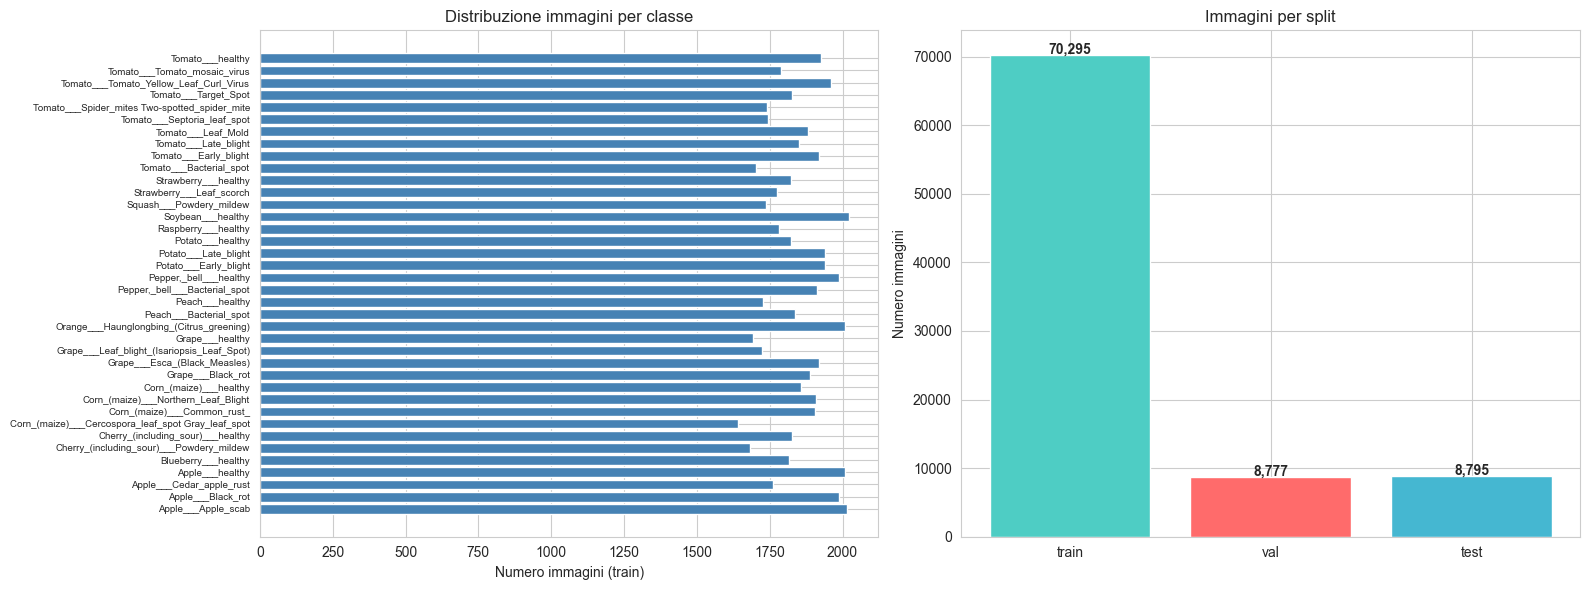

✅ Plot salvato: results/plots/00_data_exploration.png


In [6]:
train_dir = processed_dir / 'train'

class_counts = {d.name: len(get_images(d)) for d in sorted(train_dir.iterdir()) if d.is_dir()}
classes = list(class_counts.keys())
counts = list(class_counts.values())

split_totals = {
    s: sum(len(get_images(c)) for c in (processed_dir / s).iterdir() if c.is_dir())
    for s in ['train', 'val', 'test']
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(classes, counts, color='steelblue')
axes[0].set_xlabel('Numero immagini (train)')
axes[0].set_title('Distribuzione immagini per classe')
axes[0].tick_params(axis='y', labelsize=7)

colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']
bars = axes[1].bar(split_totals.keys(), split_totals.values(), color=colors)
axes[1].set_title('Immagini per split')
axes[1].set_ylabel('Numero immagini')
for bar, v in zip(bars, split_totals.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plot_path = ROOT / 'results' / 'plots' / '00_data_exploration.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Plot salvato: {plot_path.relative_to(ROOT)}')

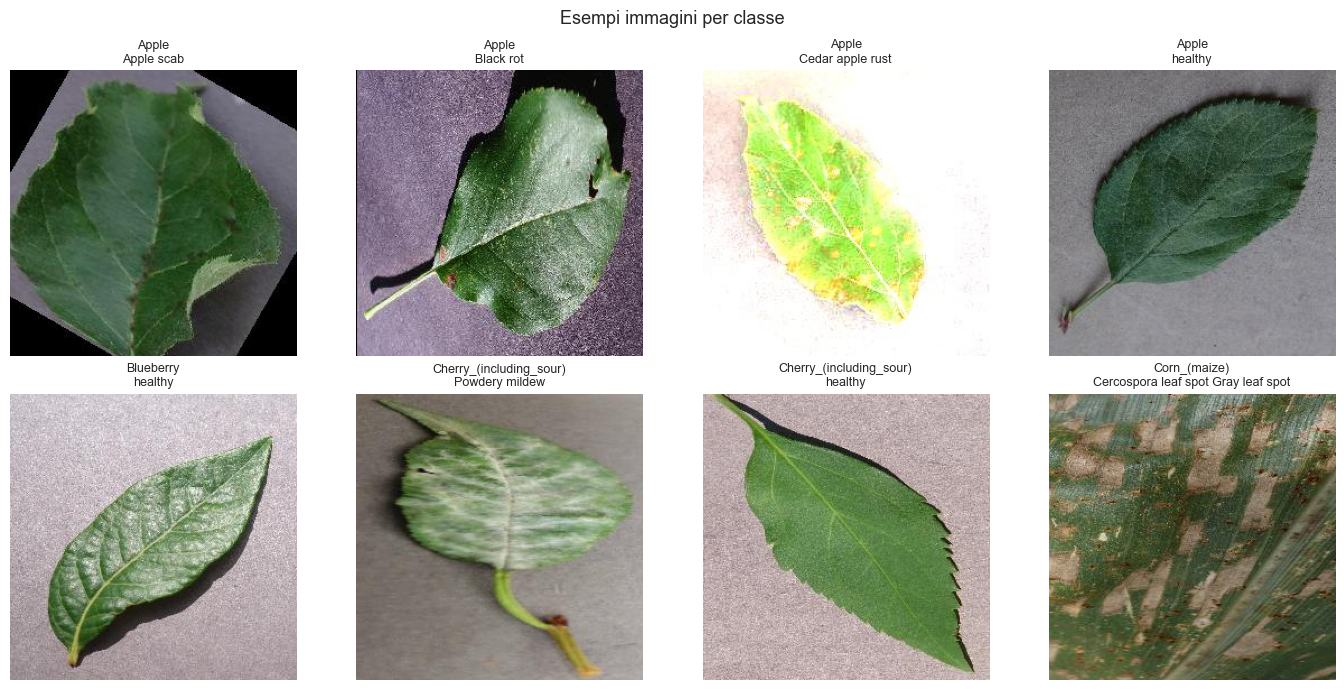


✅ Notebook 00 completato!
   Classi: 38
   Totale immagini: 87,867

➡️  Prosegui con: 01_v1_hog_svm.ipynb


In [7]:
from matplotlib.image import imread

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, class_name in zip(axes.flatten(), classes[:8]):
    img_files = get_images(train_dir / class_name)
    if img_files:
        ax.imshow(imread(str(img_files[0])))
        parts = class_name.split('___')
        label = f"{parts[0]}\n{parts[1].replace('_', ' ')}" if len(parts) == 2 else class_name
        ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.suptitle('Esempi immagini per classe', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n✅ Notebook 00 completato!')
print(f'   Classi: {len(classes)}')
print(f'   Totale immagini: {sum(split_totals.values()):,}')
print(f'\n➡️  Prosegui con: 01_v1_hog_svm.ipynb')